# Daily Challenge - Statistics for Machine Learning


# Applying Inferential Statistics


### Here are the hypotheses to test:

1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.


In [1]:
import kagglehub
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
from numpy.random import seed
from scipy.special import stdtr
from scipy.stats import t

%matplotlib inline
from matplotlib import rcParams

sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
matplotlib.rcParams["figure.figsize"] = (8.0, 5.0)

In [3]:
# load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
path = kagglehub.dataset_download("sonalidasgupta95/churn-prediction-of-bank-customers")

file_1 = f"{path}/Churn_Modelling.csv"

100%|██████████| 262k/262k [00:00<00:00, 64.3MB/s]

Extracting files...


In [4]:
# make into a dataframe called df
df = pd.read_csv(file_1)

In [5]:
# output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df["Exited"] == 0].copy()
df_1 = df[df["Exited"] == 1].copy()

display(df_0.head())
display(df_1.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
16,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1


## Hypothesis 1: Age


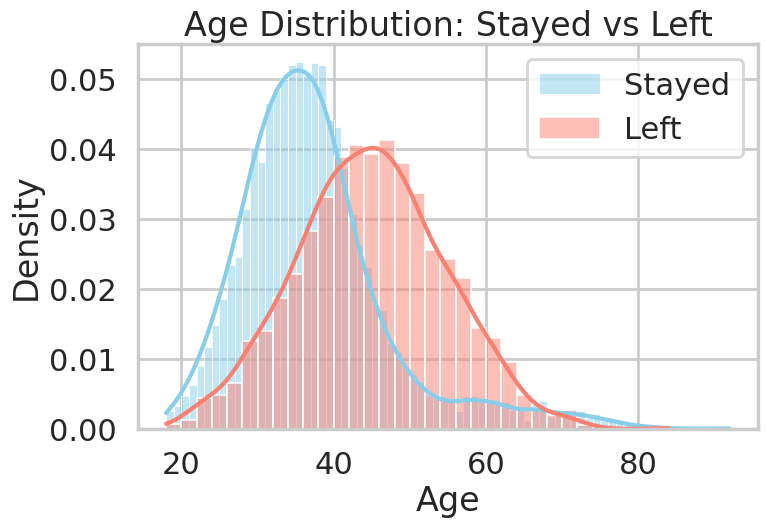

In [7]:
# Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
sns.histplot(df_0["Age"], color="skyblue", label="Stayed", kde=True, stat="density")
sns.histplot(df_1["Age"], color="salmon", label="Left", kde=True, stat="density")
plt.legend()
plt.title("Age Distribution: Stayed vs Left")
plt.show()

In [8]:
# Calculate the mean and standard deviation of the age for customers who stayed with the bank.
mean_age_0 = df_0["Age"].mean()
std_age_0 = df_0["Age"].std()

# Calculate the mean and standard deviation of the age for customers who left the bank.
mean_age_1 = df_1["Age"].mean()
std_age_1 = df_1["Age"].std()

print(f"Stayed: mean = {mean_age_0:.2f}, std = {std_age_0:.2f}")
print(f"Left: mean = {mean_age_1:.2f}, std = {std_age_1:.2f}")

Stayed: mean = 37.41, std = 10.13
Left: mean = 44.84, std = 9.76


In [9]:
# Perform a t-test to compare the ages of customers who stayed and left the bank.
t_stat, p_value = scipy.stats.ttest_ind(df_0["Age"], df_1["Age"])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Interpret the results
# Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # The conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(
        f"Looking at the age distribution plot of the customers who stayed and those who left, we already could see the hypothesis will be rejected. The `Stayed` graph has a strong right-skew, while the `Left` graph is very close to a bell curve. Also, the mean age of the customers who stayed is at {mean_age_0:.2f} while the mean age of the customers who left is {mean_age_1:.2f} which is {(mean_age_1 - mean_age_0) / mean_age_0 * 100:.2f}% difference."
    )
else:
    # The conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print(
        "No statistically significant difference was found between the ages of stayed vs. left customers."
    )


Results:
T-statistic: -29.7668
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
Looking at the age distribution plot of the customers who stayed and those who left, we already could see the hypothesis will be rejected. The `Stayed` graph has a strong right-skew, while the `Left` graph is very close to a bell curve. Also, the mean age of the customers who stayed is at 37.41 while the mean age of the customers who left is 44.84 which is 19.86% difference.


### Using Bootstrapping


In [ ]:
# Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [11]:
# Calculate the difference in means and shift the ages to the overall mean.
diff_means = mean_age_1 - mean_age_0
mean_age = df["Age"].mean()

shifted_age_0 = df_0["Age"] + mean_age - mean_age_0
shifted_age_1 = df_1["Age"] + mean_age - mean_age_1

print(f"Mean difference: {diff_means:.2f}, Total age mean: {mean_age:.2f}")

Mean difference: 7.43, Total age mean: 38.92


In [12]:
# Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
bootstrap_mean_0 = bs_choice(shifted_age_0, np.mean, 10000)
bootstrap_mean_1 = bs_choice(shifted_age_1, np.mean, 10000)
bootstrap_diff = bootstrap_mean_1 - bootstrap_mean_0
std_0, std_1, std_diff = (
    bootstrap_mean_0.std(),
    bootstrap_mean_1.std(),
    bootstrap_diff.std(),
)

print(
    f"Bootstrap mean difference range: ({bootstrap_diff.min():.2f}) <-> ({bootstrap_diff.max():.2f})"
)

Bootstrap mean difference range: (-1.03) <-> (1.02)


In [ ]:
# Calculate the p-value by comparing the difference in means to the bootstrap distribution.
p_value_bootstrap = np.sum(np.abs(bootstrap_diff) >= np.abs(diff_means)) / len(
    bootstrap_diff
)

print(f"P-value bootstrap: {p_value_bootstrap:.6f}")

P-value bootstrap: 0.000000


### Conclusion

Do we reject the Null Hypothesis? Why?

Yes, we reject the Null Hypothesis, because even after bootstrap sampling, we found that the difference in the mean we observed (between the ages of customers who left, and those who stayed) was real and not just some sort of noise. The bootstrap mean difference ranged between ~(-1.10 to 0.85) and the difference we observed was ~7.43. But what confirms it was real, was the bootstrap P-value which was 0.000000, which means that the fraction of H0-simulated outcomes that were at least as extreme as ~7.43, out of 10,000 tries, was 0.

If the bootstrap P-value was higher (e.g 0.05), we would fail to reject the Null Hypothesis (but not necessarily prove it is true).


## Hypothesis 2: Credit Score


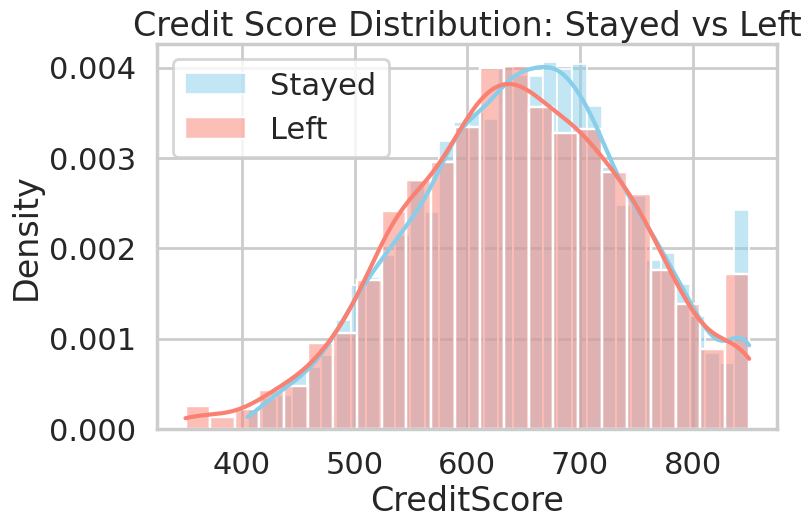

In [14]:
# Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
sns.histplot(
    df_0["CreditScore"], color="skyblue", label="Stayed", kde=True, stat="density"
)
sns.histplot(
    df_1["CreditScore"], color="salmon", label="Left", kde=True, stat="density"
)
plt.title("Credit Score Distribution: Stayed vs Left")
plt.legend()
plt.show()

In [ ]:
# Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
t_stat, p_value = scipy.stats.ttest_ind(df_0["CreditScore"], df_1["CreditScore"])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Interpret the results
# Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # The conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
else:
    # The conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print(
        "No statistically significant difference was found between the credit score of stayed vs. left customers."
    )


Results:
T-statistic: 2.7101
P-value: 0.006738

Conclusion: Reject H0 (p < 0.05)


### Conclusion

Do we reject the Null Hypothesis? Why?

Yes, we reject the Null Hypothesis, because the P-value of the two groups is less than 0.05. The groups look very similar in the plots (both close to bell curves with a slight left-skew), so we have no real reason to distrust the t-test's assumption.


## Hypothesis 3: Balance


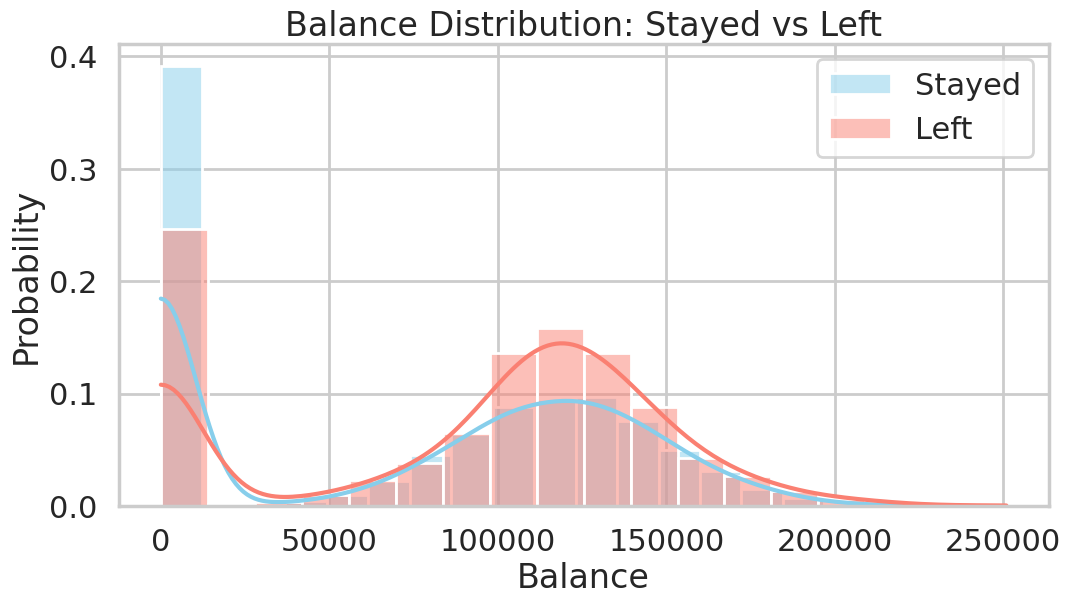

In [16]:
# Plot the distribution of Balance for both groups (Still with bank and Left the bank).
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    df_0["Balance"],
    color="skyblue",
    label="Stayed",
    kde=True,
    stat="probability",
    ax=ax,
)
sns.histplot(
    df_1["Balance"], color="salmon", label="Left", kde=True, stat="probability", ax=ax
)
plt.title("Balance Distribution: Stayed vs Left")
plt.legend()
plt.show()

In [17]:
# Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
t_stat, p_value = scipy.stats.ttest_ind(df_0["Balance"], df_1["Balance"])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Interpret the results
# Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # The conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
else:
    # The conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print(
        "No statistically significant difference was found between the balance of stayed vs. left customers."
    )


Results:
T-statistic: -11.9362
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)


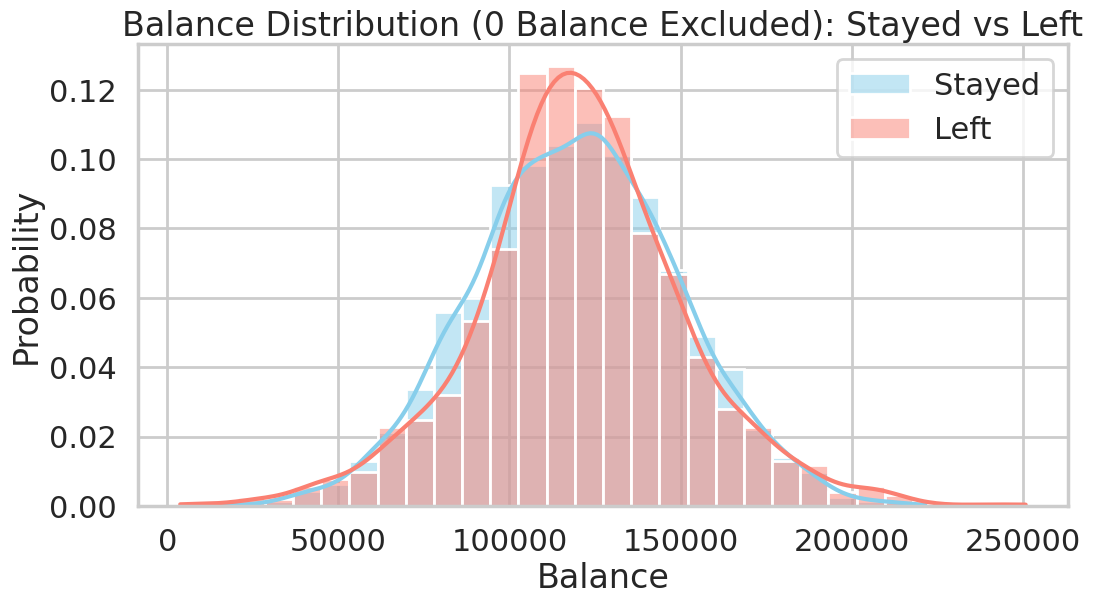

In [18]:
# Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
df_0_nonzero = df_0[df_0["Balance"] != 0]
df_1_nonzero = df_1[df_1["Balance"] != 0]

bins = np.histogram_bin_edges(
    pd.concat([df_0_nonzero["Balance"], df_1_nonzero["Balance"]]), bins=30
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    df_0_nonzero["Balance"],
    bins=bins,
    color="skyblue",
    label="Stayed",
    kde=True,
    stat="probability",
    ax=ax,
)
sns.histplot(
    df_1_nonzero["Balance"],
    bins=bins,
    color="salmon",
    label="Left",
    kde=True,
    stat="probability",
    ax=ax,
)
plt.title("Balance Distribution (0 Balance Excluded): Stayed vs Left")
plt.legend()
plt.show()

In [19]:
# Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.
t_stat, p_value = scipy.stats.ttest_ind(
    df_0_nonzero["Balance"], df_1_nonzero["Balance"]
)

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Interpret the results
# Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # The conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
else:
    # The conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print(
        "No statistically significant difference was found between the balance (0 excluded) of stayed vs. left customers."
    )



Results:
T-statistic: -1.3748
P-value: 0.169247

Conclusion: Fail to reject H0 (p >= 0.05)
No statistically significant difference was found between the balance (0 excluded) of stayed vs. left customers.


## Conclusion

Do we reject the Null Hypothesis? Why?

No, we do not reject the Null Hypothesis, in fact, we failed to reject it. Looking at the plot and the distribution of the two groups, they look very much identical (minor differences). The T-test revealed a P-value of 0.17.


## Hypothesis 4: Estimated Salary


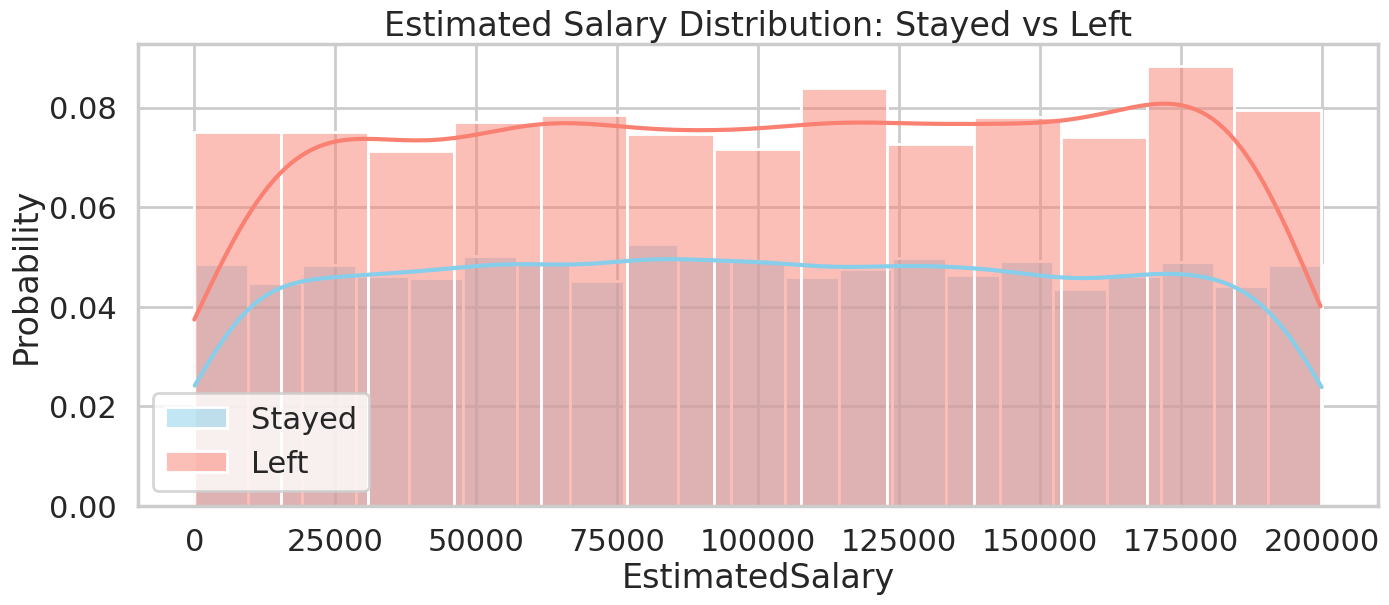

In [25]:
# Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
fig, ax = plt.subplots(figsize=(16, 6))
sns.histplot(
    df_0["EstimatedSalary"],
    color="skyblue",
    label="Stayed",
    kde=True,
    stat="probability",
    ax=ax,
)
sns.histplot(
    df_1["EstimatedSalary"],
    color="salmon",
    label="Left",
    kde=True,
    stat="probability",
    ax=ax,
)
plt.title("Estimated Salary Distribution: Stayed vs Left")
plt.legend()
plt.show()

In [ ]:
# Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
t_stat, p_value = scipy.stats.ttest_ind(
    df_0["EstimatedSalary"], df_1["EstimatedSalary"]
)

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Interpret the results
# Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # The conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
else:
    # The conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print(
        "No statistically significant difference was found between the estimated salary of stayed vs. left customers."
    )


Results:
T-statistic: -1.2097
P-value: 0.226440

Conclusion: Fail to reject H0 (p >= 0.05)
No statistically significant difference was found between the estimated salary of stayed vs. left customers.


### Using Bootstrapping


In [ ]:
# Calculate the difference in means and shift the EstimatedSalary for both groups.
mean_estimated_salary_0 = df_0["EstimatedSalary"].mean()
mean_estimated_salary_1 = df_1["EstimatedSalary"].mean()

diff_means_estimated_salary = mean_estimated_salary_1 - mean_estimated_salary_0
mean_salary = df["EstimatedSalary"].mean()

shifted_estimated_salary_0 = (
    df_0["EstimatedSalary"] + mean_salary - mean_estimated_salary_0
)
shifted_estimated_salary_1 = (
    df_1["EstimatedSalary"] + mean_salary - mean_estimated_salary_1
)

print(
    f"Mean difference: {diff_means_estimated_salary:.2f}, Total estimated salary mean: {mean_salary:.2f}"
)

Mean difference: 1727.29, Total estimated salary mean: 100090.24


In [ ]:
# Calculate the bootstrap sample means for both groups and their difference.
bootstrap_estimated_salary_mean_0 = bs_choice(
    shifted_estimated_salary_0, np.mean, 10000
)
bootstrap_estimated_salary_mean_1 = bs_choice(
    shifted_estimated_salary_1, np.mean, 10000
)
bootstrap_estimated_salary_diff = (
    bootstrap_estimated_salary_mean_1 - bootstrap_estimated_salary_mean_0
)
std_0, std_1, std_diff = (
    bootstrap_estimated_salary_mean_0.std(),
    bootstrap_estimated_salary_mean_1.std(),
    bootstrap_estimated_salary_diff.std(),
)

print(
    f"Bootstrap mean difference range: ({bootstrap_estimated_salary_diff.min():.2f}) <-> ({bootstrap_estimated_salary_diff.max():.2f})"
)

Bootstrap mean difference range: (-5652.27) <-> (5856.20)


In [ ]:
# Calculate the p-value based on the bootstrap distribution of the difference in means.
p_value_estimated_salary_bootstrap = np.sum(
    np.abs(bootstrap_estimated_salary_diff) >= np.abs(diff_means_estimated_salary)
) / len(bootstrap_estimated_salary_diff)

print(f"P-value bootstrap: {p_value_estimated_salary_bootstrap:.6f}")

P-value bootstrap: 0.233700


### Conclusion

Do we reject the Null Hypothesis? Why?

No, we do not reject the Null Hypothesis (P-value ~ 0.226, so we failed to reject H0). We observed a gap of ~1727 in estimated salary between the groups, which is small relatively to the bootstrap's range of ~(-5652.27 to 5856.20). The bootstrap's P-value is at ~ 0.234, so given all this information, we have insufficient evidence of a difference, which could have no effect at all, or a very small effect which is too small for this sample to detect.


## Final Conclusion

What will be the most helpful feature in predicting churning?

`Age` Will be the most helpful feature in predicting churning, because not only we were able to reject H0, but unlike `CreditScore`, `Age`'s effect size is at ~20% while `CreditScore`s is at ~1% (mean difference between 'Stayed' and 'Left' groups in percentage).
`EstimatedSalary` failed to reject H0, and the data itself looks very similar to uniform distribution, which means it is very likely to be randomly generated rather than representing real data.
`Balance`'s significance was an artifact of the split between zero-balance and non-zero-balance groups, so not a real magnitude difference.
